In [2]:
import pandas as pd

df = pd.read_csv("files/net_users_num.csv")
print(df.head())


       country 1990 1991 1992 1993 1994  1995  1996  1997  1998  ...   2010  \
0  Afghanistan    0    0    0    0    0     0   NaN   NaN   NaN  ...  1.17M   
1       Angola    0    0    0    0    0     0   112   844  2830  ...   654k   
2      Albania    0    0    0    0    0   348   998  1510  2020  ...  1.33M   
3      Andorra    0    0    0    0    0     0   983  1960  4420  ...  68.4k   
4          UAE    0    0    0    0    0  2490  9530   88k  194k  ...  5.81M   

    2011   2012   2013   2014   2015   2016   2017   2018   2019  
0  1.51M   1.7M   1.9M  2.34M  2.84M  3.96M   4.9M  5.02M  5.14M  
1   751k  1.63M  2.32M  5.77M  3.46M  3.75M  4.28M  4.42M  4.56M  
2  1.44M  1.59M  1.66M  1.74M  1.83M  1.92M  2.07M  2.07M  2.01M  
3  67.8k  71.2k  75.9k    76k  75.6k  75.7k  70.5k  70.5k  70.6k  
4  6.98M  7.77M  8.09M  8.33M  8.38M  8.48M     9M  9.48M  9.69M  

[5 rows x 31 columns]


In [3]:
import numpy as np

def convert_to_numeric(value):
    if pd.isna(value) or value == '':
        return np.nan
    value = str(value).strip()
    if 'M' in value:
        return float(value.replace('M', '')) * 1_000_000
    elif 'k' in value:
        return float(value.replace('k', '')) * 1_000
    try:
        return float(value)
    except ValueError:
        return np.nan  

year_columns = [col for col in df.columns if col.isdigit()]

for col in year_columns:
    df[col] = df[col].apply(convert_to_numeric)


df_cleaned = df.copy()

df_cleaned[year_columns] = df_cleaned[year_columns].interpolate(method='linear', axis=1)

df_cleaned[year_columns] = df_cleaned[year_columns].ffill(axis=1)

df_cleaned[year_columns] = df_cleaned[year_columns].bfill(axis=1)

df_cleaned.fillna(0, inplace=True)

print("5 ردیف اول DataFrame تمیز شده:")
print(df_cleaned.head().to_markdown(index=False, numalign="left", stralign="left"))

print("\nاطلاعات DataFrame تمیز شده:")
print(df_cleaned.info())

5 ردیف اول DataFrame تمیز شده:
| country     | 1990   | 1991   | 1992   | 1993   | 1994   | 1995   | 1996   | 1997   | 1998   | 1999   | 2000   | 2001   | 2002   | 2003     | 2004     | 2005     | 2006     | 2007     | 2008     | 2009     | 2010     | 2011     | 2012     | 2013     | 2014     | 2015     | 2016     | 2017     | 2018     | 2019     |
|:------------|:-------|:-------|:-------|:-------|:-------|:-------|:-------|:-------|:-------|:-------|:-------|:-------|:-------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|:---------|
| Afghanistan | 0      | 0      | 0      | 0      | 0      | 0      | 170    | 340    | 510    | 680    | 850    | 1020   | 1030   | 20800    | 26200    | 314000   | 557000   | 515000   | 510000   | 1.01e+06 | 1.17e+06 | 1.51e+06 | 1.7e+06  | 1.9e+06  | 2.34e+06 | 2.84e+06 | 3.96e+06 | 4.9e+06  | 5.02e+06 | 5.14e+06 |
| Angola 

In [4]:
df_cleaned.to_csv('files/net_users_num_cleaned.csv', index=False)

{1990: {'Country': 'USA', 'User Num': 1980000.0}, 1991: {'Country': 'USA', 'User Num': 2960000.0}, 1992: {'Country': 'USA', 'User Num': 4430000.0}, 1993: {'Country': 'USA', 'User Num': 5900000.0}, 1994: {'Country': 'USA', 'User Num': 12800000.0}, 1995: {'Country': 'USA', 'User Num': 24500000.0}, 1996: {'Country': 'USA', 'User Num': 44100000.0}, 1997: {'Country': 'USA', 'User Num': 58700000.0}, 1998: {'Country': 'USA', 'User Num': 82800000.0}, 1999: {'Country': 'USA', 'User Num': 99900000.0}, 2000: {'Country': 'USA', 'User Num': 121000000.0}, 2001: {'Country': 'USA', 'User Num': 140000000.0}, 2002: {'Country': 'USA', 'User Num': 169000000.0}, 2003: {'Country': 'USA', 'User Num': 179000000.0}, 2004: {'Country': 'USA', 'User Num': 189000000.0}, 2005: {'Country': 'USA', 'User Num': 201000000.0}, 2006: {'Country': 'USA', 'User Num': 205000000.0}, 2007: {'Country': 'USA', 'User Num': 225000000.0}, 2008: {'Country': 'China', 'User Num': 306000000.0}, 2009: {'Country': 'China', 'User Num': 393

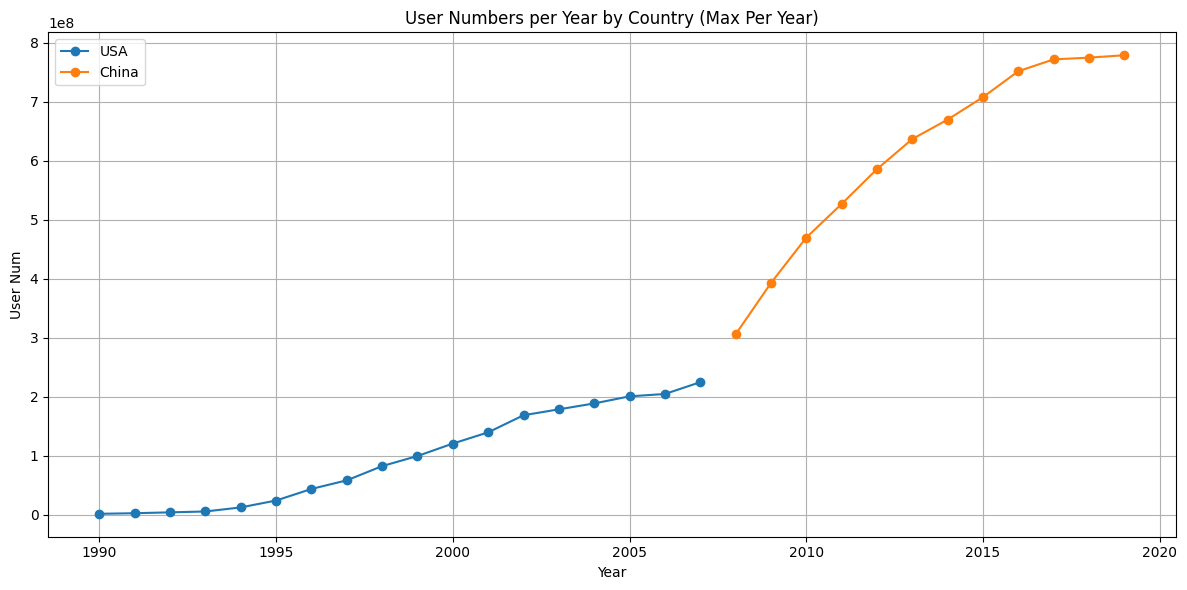

In [7]:
import matplotlib.pyplot as plt
from collections import defaultdict

max_data = {}
first_year = 1990

while first_year <= 2019 :
    max_value = df[str(first_year)].max()
    country_name = df.loc[df[str(first_year)].idxmax(), 'country']
    max_data[first_year] = {
        "Country" : country_name,
        "User Num" : max_value,
    }

    first_year += 1

print(max_data)

country_data = defaultdict(lambda: {'years': [], 'users': []})

for year, info in max_data.items():
    country = info['Country']
    users = info['User Num']
    country_data[country]['years'].append(year)
    country_data[country]['users'].append(users)

plt.figure(figsize=(12, 6))

for country, values in country_data.items():
    plt.plot(values['years'], values['users'], marker='o', label=country)

plt.title('User Numbers per Year by Country (Max Per Year)')
plt.xlabel('Year')
plt.ylabel('User Num')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()